# Chapter 6.2 - Can downstream AlphaEarth change reveal upstream mining growth?

This notebook replaces the high-versus-low difference-in-differences experiment
with a continuous change-response design.

## Research objective

To assess whether temporal changes in AlphaEarth embeddings of downstream river
reaches are associated with growth in hydrologically accumulated upstream
mining-scar area, and whether these changes provide information beyond river
morphology and geographic location.

## Why the design changed

The previous analysis reduced continuous mining growth to two classes and used
the unsigned length of the 64-dimensional change vector as its main response.
That quantity records movement in any direction, including drought, channel
migration and land-water mixing. It does not say that a reach moved towards a
mining-affected state. Moreover, 124 of 130 sampled sub-basins gained upstream
mining, so the old contrast was "much more growth" versus "less growth", not
"mining arrived" versus "no mining".

## New design

1. Pair the same river reaches in 2019 and 2024.
2. Calculate continuous upstream AMW scar density in both years through the
   HydroBASINS network.
3. Aggregate reaches to the level-12 sub-basin, because mining exposure is
   defined at that level.
4. Retain the full continuous growth gradient rather than discarding its middle.
5. Learn a signed AlphaEarth change direction with ridge regression inside each
   training fold only.
6. Hold out entire PFAF catchments and compare:
   - geographic and river context without any mining inventory;
   - the same context plus AlphaEarth change (primary test);
   - context plus historical mining, with and without AlphaEarth change
     (strict sensitivity test).
7. Report whether AlphaEarth reduces out-of-catchment prediction error first
   without assuming that historical upstream mining is known, then under the
   much stricter historical-mining benchmark. A high score alone is not evidence
   of a downstream mining signal.

The primary target is log-transformed growth in upstream AMW scar density. This
is a predictive association study, not a causal estimate of pollution. If paired
NDTI-by-basin files are present, the notebook also tests the physically
interpretable change in NDTI as a separate secondary analysis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# 1. Environment, configuration and figure style
# ============================================================
from google.colab import drive
import os, re, sys, glob, math, json, warnings, subprocess
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings('ignore')

for pkg in ['geopandas', 'rasterio']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import numpy as np, pandas as pd
import geopandas as gpd, rasterio
from rasterio.features import geometry_mask
import matplotlib as mpl, matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

SEARCH_DIRS = [Path('/content/drive/MyDrive/dissertation'),
               Path('/content/drive/MyDrive/dissertation/data'),
               Path('/content/drive/MyDrive'), Path('/content'), Path('.')]
OUT_DIR = Path('/content/drive/MyDrive/dissertation/results_continuous_change')
if not Path('/content/drive/MyDrive').exists():
    OUT_DIR = Path('./results_continuous_change')
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR/'figures').mkdir(exist_ok=True)

YEAR_PRE, YEAR_POST = 2019, 2024
BASIN_TAG   = 'TAPAJOS_CUSTOM'
BASINS_GLOB = f'sa9_v8_basins_{BASIN_TAG}.geojson'
AMW_GLOB    = 'amw_scar2024*.tif'
NDTI_GLOB   = f'sa9_v8_basin_ndti_byBasin_{{year}}_{BASIN_TAG}*.csv'

MIN_PERIOD       = 2018
WATER_FRAC_MIN   = 0.30
GROUP_PFAF_LEN   = 8
N_FOLDS          = 5
MAX_HOPS         = 400
N_BOOT           = 2000
RIDGE_ALPHAS     = np.logspace(-3, 4, 16)

ALPHA = [f'A{i:02d}' for i in range(64)]
DELTA = [f'D{i:02d}' for i in range(64)]

PAL = {'blue':'#2a78d6', 'orange':'#eb6834', 'green':'#1baf7a',
       'red':'#e34948', 'surface':'#fcfcfb', 'ink':'#0b0b0b',
       'ink2':'#52514e', 'muted':'#8a8983', 'grid':'#e5e4e0'}
mpl.rcParams.update({
    'figure.dpi':120, 'savefig.dpi':300,
    'figure.facecolor':PAL['surface'], 'axes.facecolor':PAL['surface'],
    'savefig.facecolor':PAL['surface'], 'savefig.bbox':'tight',
    'font.size':9, 'axes.titlesize':10, 'axes.labelsize':9,
    'axes.labelcolor':PAL['ink2'], 'text.color':PAL['ink'],
    'xtick.color':PAL['ink2'], 'ytick.color':PAL['ink2'],
    'axes.edgecolor':PAL['grid'], 'axes.linewidth':0.8,
    'axes.spines.top':False, 'axes.spines.right':False,
    'grid.color':PAL['grid'], 'grid.linewidth':0.6,
    'legend.frameon':False, 'lines.linewidth':2.0, 'lines.markersize':5})


def save_fig(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(OUT_DIR/'figures'/f'{name}.{ext}')
    print('saved:', name)


def find_all(pattern):
    hits, seen, out = [], set(), []
    for directory in SEARCH_DIRS:
        hits += sorted(glob.glob(str(directory/pattern)))
    for hit in hits:
        key = Path(hit).name
        if key not in seen:
            seen.add(key)
            out.append(hit)
    return out


def find_one(pattern):
    hits = find_all(pattern)
    if not hits:
        raise FileNotFoundError(f'nothing matching {pattern} in SEARCH_DIRS')
    return hits[0]


def load_year(year):
    # Read only one corridor width and keep one row per station.
    pattern = f'sa9_v8_basin_alphaSt_{year}_{BASIN_TAG}_b*.csv'
    paths = find_all(pattern)
    if not paths:
        raise FileNotFoundError(
            f'no station files for {year} matching {pattern}. '
            f'Export the same station geometry for both years.')
    by_width = {}
    for path in paths:
        match = re.search(r'_b(\d+)', Path(path).name)
        by_width.setdefault(int(match.group(1)) if match else -1, []).append(path)
    if len(by_width) > 1:
        keep = max(by_width)
        print(f'  {year}: several corridor widths found; keeping {keep} m')
        paths = by_width[keep]
    frame = pd.concat([pd.read_csv(path) for path in paths], ignore_index=True)
    n_raw = len(frame)
    missing = [column for column in ALPHA + ['station_id', 'lon', 'lat']
               if column not in frame.columns]
    if missing:
        raise ValueError(f'{year} station files are missing columns: {missing}')
    frame = frame.dropna(subset=ALPHA + ['lon', 'lat']).copy()
    frame['station_id'] = frame.station_id.astype(str)
    frame = frame.drop_duplicates(subset='station_id', keep='first')
    print(f'  {year}: {len(paths)} files, {n_raw:,} rows -> '
          f'{len(frame):,} stations with embeddings')
    return frame


print('Output directory:', OUT_DIR)

Output directory: /content/drive/MyDrive/dissertation/results_continuous_change


In [3]:
# ============================================================
# 2. Pair each river reach with itself in 2019 and 2024
# ============================================================
pre = load_year(YEAR_PRE)
post = load_year(YEAR_POST)

keys = ['station_id']
carry = [c for c in ['lon', 'lat', 'riv_ord', 'reach_len_m', 'jrc_occ',
                     'water_frac', 'n_points'] if c in post.columns]
post_table = post[keys + carry + ALPHA].rename(
    columns={a: a + '_post' for a in ALPHA})
pre_table = pre[keys + ALPHA].rename(
    columns={a: a + '_pre' for a in ALPHA})
d = post_table.merge(pre_table, on='station_id', how='inner')

print(f'\nstations in {YEAR_POST}: {len(post):,}; '
      f'in {YEAR_PRE}: {len(pre):,}; in both: {len(d):,}')
if len(d) < 100:
    raise RuntimeError('fewer than 100 paired stations; check that both exports '
                       'used the same station geometry and corridor width')

A_post = d[[a + '_post' for a in ALPHA]].values.astype(float)
A_pre = d[[a + '_pre' for a in ALPHA]].values.astype(float)
change = A_post - A_pre
for index, column in enumerate(DELTA):
    d[column] = change[:, index]

# These unsigned quantities are retained only as diagnostics. They are not the
# primary river-impact outcomes because movement in any direction contributes.
d['d_norm'] = np.linalg.norm(change, axis=1)
denominator = np.linalg.norm(A_pre, axis=1) * np.linalg.norm(A_post, axis=1)
d['d_angle'] = 1.0 - np.einsum(
    'ij,ij->i', A_pre, A_post) / np.maximum(denominator, 1e-12)
d['is_water'] = (d.water_frac >= WATER_FRAC_MIN
                 if 'water_frac' in d.columns else True)

print(f'stations with >= {WATER_FRAC_MIN:.0%} permanent water: '
      f'{int(d.is_water.sum()):,} ({d.is_water.mean():.1%})')
print('unsigned embedding-change diagnostics:')
print('  ||delta||', d.d_norm.quantile([.1, .5, .9]).round(3).to_dict())
print('  1-cos   ', d.d_angle.quantile([.1, .5, .9]).round(4).to_dict())

  2019: 5 files, 2,251 rows -> 779 stations with embeddings
  2024: 5 files, 2,192 rows -> 770 stations with embeddings

stations in 2024: 770; in 2019: 779; in both: 619
stations with >= 30% permanent water: 279 (45.1%)
unsigned embedding-change diagnostics:
  ||delta|| {0.1: 0.123, 0.5: 0.164, 0.9: 0.235}
  1-cos    {0.1: 0.0082, 0.5: 0.0147, 0.9: 0.0303}


In [4]:
# ============================================================
# 3. Recover upstream mining area in both years from the AMW raster
# ============================================================
basins = gpd.read_file(find_one(BASINS_GLOB))
if basins.crs is None:
    basins = basins.set_crs('EPSG:4326')
basins = basins.to_crs('EPSG:4326')
for column in ['HYBAS_ID', 'NEXT_DOWN']:
    basins[column] = basins[column].astype('int64')
print('basins:', len(basins), 'level-12 sub-basins')

cache_path = OUT_DIR/f'cache_amw_basin_area_{YEAR_PRE}_{YEAR_POST}_{BASIN_TAG}.csv'
cache_ok = False
if cache_path.exists():
    cache = pd.read_csv(cache_path)
    required = {'HYBAS_ID', f'mine_ha_{YEAR_PRE}', f'mine_ha_{YEAR_POST}'}
    if required.issubset(cache.columns):
        cache['HYBAS_ID'] = cache.HYBAS_ID.astype('int64')
        lookup = cache.set_index('HYBAS_ID')
        coverage = basins.HYBAS_ID.isin(lookup.index).mean()
        if coverage > 0.99:
            for column in [f'mine_ha_{YEAR_PRE}', f'mine_ha_{YEAR_POST}']:
                basins[column] = basins.HYBAS_ID.map(lookup[column]).fillna(0)
            cache_ok = True
            print('loaded cached AMW-by-basin table:', cache_path.name)

if not cache_ok:
    amw_path = find_one(AMW_GLOB)
    src = rasterio.open(amw_path)
    geographic = bool(src.crs and src.crs.is_geographic)
    print(f'AMW: {Path(amw_path).name}; {src.width:,} x {src.height:,}; '
          f'{src.dtypes[0]}; {src.crs}')
    bas = basins.to_crs(src.crs) if str(src.crs) != 'EPSG:4326' else basins

    def metres_per_degree(latitude):
        phi = math.radians(latitude)
        m_lat = (111132.92 - 559.82*math.cos(2*phi)
                 + 1.175*math.cos(4*phi) - 0.0023*math.cos(6*phi))
        m_lon = (111412.84*math.cos(phi) - 93.5*math.cos(3*phi)
                 + 0.118*math.cos(5*phi))
        return m_lon, m_lat

    def mine_ha(geometry, year, full_res=True):
        try:
            window = rasterio.windows.from_bounds(
                *geometry.bounds, transform=src.transform)
            window = window.round_offsets().round_lengths()
            if window.width < 1 or window.height < 1:
                return 0.0
            if full_res:
                array = src.read(1, window=window)
                out_h, out_w = array.shape
            else:
                overview = max(
                    [o for o in ([1] + list(src.overviews(1))) if o <= 8])
                out_h = max(int(window.height // overview), 1)
                out_w = max(int(window.width // overview), 1)
                array = src.read(1, window=window, out_shape=(out_h, out_w))
            if array.size == 0:
                return 0.0
            hit = ((array >= MIN_PERIOD) & (array <= year)
                   if full_res else array > 0)
            if not hit.any():
                return 0.0
            transform = src.window_transform(window)
            transform = transform * transform.scale(
                window.width/out_w, window.height/out_h)
            inside = ~geometry_mask(
                [geometry], out_shape=array.shape, transform=transform,
                invert=False)
            n_pixels = int((hit & inside).sum())
            if not n_pixels:
                return 0.0
            if geographic:
                m_lon, m_lat = metres_per_degree(geometry.centroid.y)
                pixel_m2 = abs(transform.a)*m_lon*abs(transform.e)*m_lat
            else:
                pixel_m2 = abs(transform.a*transform.e)
            return float(n_pixels*pixel_m2/1e4)
        except Exception:
            return 0.0

    print('pass 1 - locating sub-basins that overlap a non-zero AMW pixel')
    candidates = np.where(np.array([
        mine_ha(geometry, 9999, full_res=False)
        for geometry in bas.geometry]) > 0)[0]
    print(f'  {len(candidates):,} candidate sub-basins')

    h_pre = np.zeros(len(bas))
    h_post = np.zeros(len(bas))
    print('pass 2 - measuring native-resolution scar area')
    for number, index in enumerate(candidates):
        geometry = bas.geometry.iloc[index]
        h_pre[index] = mine_ha(geometry, YEAR_PRE)
        h_post[index] = mine_ha(geometry, YEAR_POST)
        if number and number % 150 == 0:
            print(f'  {number}/{len(candidates)}')
    src.close()
    basins[f'mine_ha_{YEAR_PRE}'] = h_pre
    basins[f'mine_ha_{YEAR_POST}'] = h_post
    basins[['HYBAS_ID', f'mine_ha_{YEAR_PRE}',
            f'mine_ha_{YEAR_POST}']].to_csv(cache_path, index=False)
    print('saved reusable cache:', cache_path.name)

total_pre = basins[f'mine_ha_{YEAR_PRE}'].sum()
total_post = basins[f'mine_ha_{YEAR_POST}'].sum()
print(f'\nmined by {YEAR_PRE}: {total_pre:,.0f} ha')
print(f'mined by {YEAR_POST}: {total_post:,.0f} ha')
print(f'growth: {(total_post/max(total_pre, 1e-9)-1):+.1%}')
if total_post <= total_pre:
    raise RuntimeError('AMW shows no positive aggregate growth; check its year codes')

basins: 4170 level-12 sub-basins
loaded cached AMW-by-basin table: cache_amw_basin_area_2019_2024_TAPAJOS_CUSTOM.csv

mined by 2019: 157,008 ha
mined by 2024: 265,274 ha
growth: +69.0%


In [5]:
# ============================================================
# 4. Accumulate mining downstream and build one row per sub-basin
# ============================================================
next_down = dict(zip(basins.HYBAS_ID, basins.NEXT_DOWN))


def accumulate_downstream(column):
    own = dict(zip(basins.HYBAS_ID, basins[column]))
    accumulated = defaultdict(float)
    for basin_id in basins.HYBAS_ID:
        amount = own.get(basin_id, 0.0)
        current, hops = basin_id, 0
        while current and current != 0 and hops < MAX_HOPS:
            accumulated[current] += amount
            current = next_down.get(current, 0)
            hops += 1
    return basins.HYBAS_ID.map(accumulated).fillna(0)


upstream_area = basins.UP_AREA.replace(0, np.nan)
basins['dose_pre'] = (
    1000*accumulate_downstream(f'mine_ha_{YEAR_PRE}')/upstream_area)
basins['dose_post'] = (
    1000*accumulate_downstream(f'mine_ha_{YEAR_POST}')/upstream_area)
basins['ddose'] = (basins.dose_post-basins.dose_pre).clip(lower=0)
basins['self_mined_post'] = basins[f'mine_ha_{YEAR_POST}'] > 0

# Locate paired stations in level-12 basins.
points = gpd.GeoDataFrame(
    d, geometry=gpd.points_from_xy(d.lon, d.lat), crs='EPSG:4326')
joined = gpd.sjoin(
    points, basins[['HYBAS_ID', 'geometry']], how='left', predicate='within')
joined = joined[~joined.index.duplicated(keep='first')]
# Join back by the original row index. This remains correct even if GeoPandas
# changes the row ordering returned by the spatial join.
d['HYBAS_ID'] = d.index.to_series().map(joined.HYBAS_ID)
n_outside = int(d.HYBAS_ID.isna().sum())
d = d.dropna(subset=['HYBAS_ID']).copy()
d['HYBAS_ID'] = d.HYBAS_ID.astype('int64')

basin_lookup = basins.set_index('HYBAS_ID')
for column in ['dose_pre', 'dose_post', 'ddose', 'self_mined_post',
               'PFAF_ID', 'UP_AREA', 'SUB_AREA']:
    d[column] = d.HYBAS_ID.map(basin_lookup[column])
print(f'paired stations assigned to basins: {len(d):,}; '
      f'dropped outside: {n_outside:,}')

# Local mining is excluded so the embedding cannot simply read the mine itself.
eligible = d[d.is_water & ~d.self_mined_post.astype(bool)].copy()

# Exposure is constant inside a level-12 basin, so using every station as an
# independent observation would create pseudoreplication. Median aggregation
# retains the typical river state while preserving the true exposure unit.
median_columns = DELTA + [
    'lon', 'lat', 'riv_ord', 'water_frac', 'd_norm', 'd_angle']
median_columns = [c for c in median_columns if c in eligible.columns]
first_columns = [
    'dose_pre', 'dose_post', 'ddose', 'UP_AREA', 'SUB_AREA', 'PFAF_ID']
first_columns = [c for c in first_columns if c in eligible.columns]

bdf = eligible.groupby('HYBAS_ID')[median_columns].median()
bdf = bdf.join(eligible.groupby('HYBAS_ID')[first_columns].first())
bdf['n_reaches'] = eligible.groupby('HYBAS_ID').size()
bdf = bdf.reset_index()
bdf['pfaf_group'] = (
    bdf.PFAF_ID.astype('int64').astype(str).str[:GROUP_PFAF_LEN])

# Continuous target and baseline controls.
bdf['growth_log'] = np.log1p(bdf.ddose.clip(lower=0))
bdf['dose_pre_log'] = np.log1p(bdf.dose_pre.clip(lower=0))
bdf['up_area_log'] = np.log1p(bdf.UP_AREA.clip(lower=0))
bdf['sub_area_log'] = np.log1p(bdf.SUB_AREA.clip(lower=0))
bdf['lon_c'] = bdf.lon-bdf.lon.median()
bdf['lat_c'] = bdf.lat-bdf.lat.median()
bdf['lon_c2'] = bdf.lon_c**2
bdf['lat_c2'] = bdf.lat_c**2
bdf['lon_lat'] = bdf.lon_c*bdf.lat_c

# The primary context deliberately contains no mining inventory. Historical
# upstream mining is introduced only in the separate sensitivity analysis.
RIVER_CONTEXT = [c for c in ['riv_ord', 'water_frac', 'up_area_log',
                             'sub_area_log'] if c in bdf.columns]
GEOGRAPHY = ['lon_c', 'lat_c', 'lon_c2', 'lat_c2', 'lon_lat']
CONTEXT = RIVER_CONTEXT + GEOGRAPHY
HISTORY = ['dose_pre_log']
STRICT_BASELINE = CONTEXT + HISTORY
required = list(dict.fromkeys(
    STRICT_BASELINE + DELTA + ['growth_log', 'pfaf_group']))
bdf = bdf.dropna(subset=required).copy()

print('\n=== Continuous analysis sample ===')
print(f'{len(bdf):,} level-12 sub-basins; '
      f'{bdf.pfaf_group.nunique():,} independent PFAF groups; '
      f'{int(bdf.n_reaches.sum()):,} contributing reaches')
print('upstream mining growth, ha per 1000 km2:')
print(bdf.ddose.quantile([0, .1, .25, .5, .75, .9, 1]).round(1).to_string())
print('baseline upstream mining density:')
print(bdf.dose_pre.quantile([.1, .5, .9]).round(1).to_string())
print('\nThe analysis retains every eligible basin; no high/low labels are made.')
if len(bdf) < 60 or bdf.pfaf_group.nunique() < 10:
    raise RuntimeError('too few independent basins/groups for grouped validation')

bdf.to_csv(OUT_DIR/'table_6_6_continuous_sample.csv', index=False)

paired stations assigned to basins: 619; dropped outside: 0

=== Continuous analysis sample ===
130 level-12 sub-basins; 56 independent PFAF groups; 214 contributing reaches
upstream mining growth, ha per 1000 km2:
0.00       0.0
0.10       1.0
0.25      77.9
0.50     181.3
0.75     225.2
0.90     575.5
1.00    1614.1
baseline upstream mining density:
0.1      0.2
0.5    314.6
0.9    632.9

The analysis retains every eligible basin; no high/low labels are made.


In [6]:
# ============================================================
# 5. Grouped continuous prediction and incremental-value test
# ============================================================
def choose_ridge_alpha(X, y, groups):
    n_groups = len(np.unique(groups))
    n_splits = min(4, n_groups)
    if n_splits < 2:
        return 1.0
    splitter = GroupKFold(n_splits=n_splits)
    scores = []
    for alpha in RIDGE_ALPHAS:
        fold_mae = []
        for train_index, test_index in splitter.split(X, y, groups):
            model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
            model.fit(X[train_index], y[train_index])
            prediction = model.predict(X[test_index])
            fold_mae.append(mean_absolute_error(y[test_index], prediction))
        scores.append(np.mean(fold_mae))
    return float(RIDGE_ALPHAS[int(np.argmin(scores))])


def grouped_oof(frame, features, target='growth_log'):
    clean = frame.dropna(subset=features + [target, 'pfaf_group']).copy()
    X = clean[features].values.astype(float)
    y = clean[target].values.astype(float)
    groups = clean.pfaf_group.astype(str).values
    n_splits = min(N_FOLDS, len(np.unique(groups)))
    if n_splits < 2:
        raise RuntimeError('not enough PFAF groups for cross-validation')
    prediction = np.full(len(clean), np.nan)
    null_prediction = np.full(len(clean), np.nan)
    selected_alphas = []
    outer = GroupKFold(n_splits=n_splits)
    for train_index, test_index in outer.split(X, y, groups):
        alpha = choose_ridge_alpha(
            X[train_index], y[train_index], groups[train_index])
        selected_alphas.append(alpha)
        model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
        model.fit(X[train_index], y[train_index])
        prediction[test_index] = model.predict(X[test_index])
        null_prediction[test_index] = np.mean(y[train_index])
    ok = np.isfinite(prediction)
    rho, p_value = stats.spearmanr(y[ok], prediction[ok])
    metrics = {
        'n_basins': int(ok.sum()),
        'n_groups': int(len(np.unique(groups[ok]))),
        'mae': mean_absolute_error(y[ok], prediction[ok]),
        'rmse': mean_squared_error(y[ok], prediction[ok])**0.5,
        'r2': r2_score(y[ok], prediction[ok]),
        'spearman_rho': float(rho),
        'spearman_p': float(p_value),
        'null_mae': mean_absolute_error(y[ok], null_prediction[ok]),
        'median_alpha': float(np.median(selected_alphas))}
    return clean, prediction, null_prediction, metrics


blocks = [
    ('geography only', GEOGRAPHY),
    ('river context only', RIVER_CONTEXT),
    ('context baseline', CONTEXT),
    ('unsigned magnitude only', ['d_norm', 'd_angle']),
    ('AlphaEarth change only', DELTA),
    ('context + AlphaEarth change', CONTEXT + DELTA),
    ('context + historical mining', STRICT_BASELINE),
    ('context + historical mining + AlphaEarth change',
     STRICT_BASELINE + DELTA)]

rows, predictions = [], {}
for name, features in blocks:
    frame, pred, null_pred, metrics = grouped_oof(bdf, features)
    metrics.update({'model': name, 'n_features': len(features)})
    rows.append(metrics)
    predictions[name] = (frame.index.to_numpy(), pred)

results = pd.DataFrame(rows)
columns = ['model', 'n_features', 'n_basins', 'n_groups', 'mae', 'rmse',
           'r2', 'spearman_rho', 'spearman_p', 'null_mae', 'median_alpha']
print('=== Out-of-catchment prediction of continuous mining growth ===\n')
print(results[columns].round(4).to_string(index=False))

# Put all OOF predictions on the common bdf index.
for name, (index, pred) in predictions.items():
    bdf.loc[index, 'pred_' + re.sub(r'[^a-z0-9]+', '_', name.lower()).strip('_')] = pred

delta_col = 'pred_alphaearth_change_only'
context_col = 'pred_context_baseline'
context_alpha_col = 'pred_context_alphaearth_change'
history_col = 'pred_context_historical_mining'
history_alpha_col = 'pred_context_historical_mining_alphaearth_change'


def cluster_boot_increment(frame, base_col, full_col, comparison,
                           n=N_BOOT, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    group_values = frame.pfaf_group.astype(str).values
    unique_groups = np.unique(group_values)
    group_index = {group: np.where(group_values == group)[0]
                   for group in unique_groups}
    y = frame.growth_log.values
    base = frame[base_col].values
    full = frame[full_col].values
    d_mae, d_r2 = [], []
    for _ in range(n):
        selected = rng.choice(unique_groups, len(unique_groups), replace=True)
        index = np.concatenate([group_index[group] for group in selected])
        if len(np.unique(y[index])) < 2:
            continue
        d_mae.append(mean_absolute_error(y[index], base[index])
                     - mean_absolute_error(y[index], full[index]))
        d_r2.append(r2_score(y[index], full[index])
                    - r2_score(y[index], base[index]))
    return {
        'comparison': comparison,
        'mae_gain': float(np.mean(d_mae)),
        'mae_ci_lo': float(np.percentile(d_mae, 2.5)),
        'mae_ci_hi': float(np.percentile(d_mae, 97.5)),
        'r2_gain': float(np.mean(d_r2)),
        'r2_ci_lo': float(np.percentile(d_r2, 2.5)),
        'r2_ci_hi': float(np.percentile(d_r2, 97.5))}


primary_increment = cluster_boot_increment(
    bdf, context_col, context_alpha_col,
    'AlphaEarth over non-mining context')
strict_increment = cluster_boot_increment(
    bdf, history_col, history_alpha_col,
    'AlphaEarth over context plus historical mining',
    seed=RANDOM_SEED + 1)
increments = pd.DataFrame([primary_increment, strict_increment])

print('\n=== Primary test: does AlphaEarth add to non-mining context? ===')
print(f"MAE reduction: {primary_increment['mae_gain']:+.4f} "
      f"[95% catchment bootstrap {primary_increment['mae_ci_lo']:+.4f}, "
      f"{primary_increment['mae_ci_hi']:+.4f}]")
print(f"R2 increase:   {primary_increment['r2_gain']:+.4f} "
      f"[95% catchment bootstrap {primary_increment['r2_ci_lo']:+.4f}, "
      f"{primary_increment['r2_ci_hi']:+.4f}]")

print('\n=== Strict sensitivity: does AlphaEarth add after mining history? ===')
print(f"MAE reduction: {strict_increment['mae_gain']:+.4f} "
      f"[95% catchment bootstrap {strict_increment['mae_ci_lo']:+.4f}, "
      f"{strict_increment['mae_ci_hi']:+.4f}]")
print(f"R2 increase:   {strict_increment['r2_gain']:+.4f} "
      f"[95% catchment bootstrap {strict_increment['r2_ci_lo']:+.4f}, "
      f"{strict_increment['r2_ci_hi']:+.4f}]")

results.to_csv(OUT_DIR/'table_6_7_continuous_models.csv', index=False)
increments.to_csv(
    OUT_DIR/'table_6_8_alphaearth_increment.csv', index=False)
bdf.to_csv(OUT_DIR/'table_6_9_continuous_oof_predictions.csv', index=False)

=== Out-of-catchment prediction of continuous mining growth ===

                                          model  n_features  n_basins  n_groups    mae   rmse      r2  spearman_rho  spearman_p  null_mae  median_alpha
                                 geography only           5       130        56 1.3310 1.8162  0.0685        0.5801      0.0000    1.5194        1.8478
                             river context only           4       130        56 1.2860 1.6528  0.2286        0.3821      0.0000    1.5194       15.8489
                               context baseline           9       130        56 1.1267 1.4436  0.4115        0.7068      0.0000    1.5194        1.8478
                        unsigned magnitude only           2       130        56 1.5432 1.9874 -0.1154       -0.1054      0.2326    1.5194       15.8489
                         AlphaEarth change only          64       130        56 1.3096 1.7223  0.1623        0.5495      0.0000    1.5194      135.9356
                    con

In [7]:
# ============================================================
# 6. Optional physical comparator: paired basin NDTI
# ============================================================
def load_ndti_year(year):
    paths = find_all(NDTI_GLOB.format(year=year))
    if not paths:
        return None
    frame = pd.concat([pd.read_csv(path) for path in paths], ignore_index=True)
    if 'HYBAS_ID' not in frame.columns or 'ndti_mean' not in frame.columns:
        print(f'NDTI {year} files found but required columns are missing')
        return None
    frame = frame.dropna(subset=['HYBAS_ID', 'ndti_mean']).copy()
    frame['HYBAS_ID'] = frame.HYBAS_ID.astype('int64')
    return frame.groupby('HYBAS_ID', as_index=False).agg(
        ndti_mean=('ndti_mean', 'mean'),
        n_water_px=('n_water_px', 'sum') if 'n_water_px' in frame.columns
                   else ('ndti_mean', 'size'))


ndti_pre = load_ndti_year(YEAR_PRE)
ndti_post = load_ndti_year(YEAR_POST)
ndti_results = pd.DataFrame()

if ndti_pre is not None and ndti_post is not None:
    ndti = ndti_pre.rename(columns={'ndti_mean':'ndti_pre'}).merge(
        ndti_post.rename(columns={'ndti_mean':'ndti_post'}),
        on='HYBAS_ID', how='inner', suffixes=('_pre_count', '_post_count'))
    ndti['ndti_change'] = ndti.ndti_post-ndti.ndti_pre
    bn = bdf.merge(ndti[['HYBAS_ID', 'ndti_pre', 'ndti_post', 'ndti_change']],
                   on='HYBAS_ID', how='inner')
    print(f'paired NDTI available for {len(bn):,} analysis basins')
    if len(bn) >= 40 and bn.pfaf_group.nunique() >= 8:
        rho, p_value = stats.spearmanr(bn.ddose, bn.ndti_change)
        print(f'raw continuous association: Spearman rho={rho:.3f}, p={p_value:.4g}')

        # This comparator follows the same primary logic: river/geographic
        # context and baseline NDTI, but no prior mining inventory.
        ndti_base_features = CONTEXT + ['ndti_pre']
        _, pred0, _, met0 = grouped_oof(
            bn, ndti_base_features, target='ndti_change')
        _, pred1, _, met1 = grouped_oof(
            bn, ndti_base_features + ['growth_log'], target='ndti_change')
        ndti_results = pd.DataFrame([
            {'model':'static + baseline NDTI', **met0},
            {'model':'static + baseline NDTI + mining growth', **met1}])
        print('\n=== Does mining growth improve prediction of NDTI change? ===')
        print(ndti_results[['model','n_basins','mae','r2',
                            'spearman_rho']].round(4).to_string(index=False))
        ndti_results.to_csv(
            OUT_DIR/'table_6_10_ndti_change_models.csv', index=False)
        bn.to_csv(OUT_DIR/'table_6_11_paired_ndti.csv', index=False)
    else:
        print('too few paired NDTI basins for grouped analysis')
else:
    print('Optional NDTI analysis skipped.')
    print('To enable it, export both:')
    print(' ', NDTI_GLOB.format(year=YEAR_PRE))
    print(' ', NDTI_GLOB.format(year=YEAR_POST))
    print('from GEE_6 with EXPORT_WHICH = ndti_basin.')

Optional NDTI analysis skipped.
To enable it, export both:
  sa9_v8_basin_ndti_byBasin_2019_TAPAJOS_CUSTOM*.csv
  sa9_v8_basin_ndti_byBasin_2024_TAPAJOS_CUSTOM*.csv
from GEE_6 with EXPORT_WHICH = ndti_basin.


saved: F6_2_continuous_change


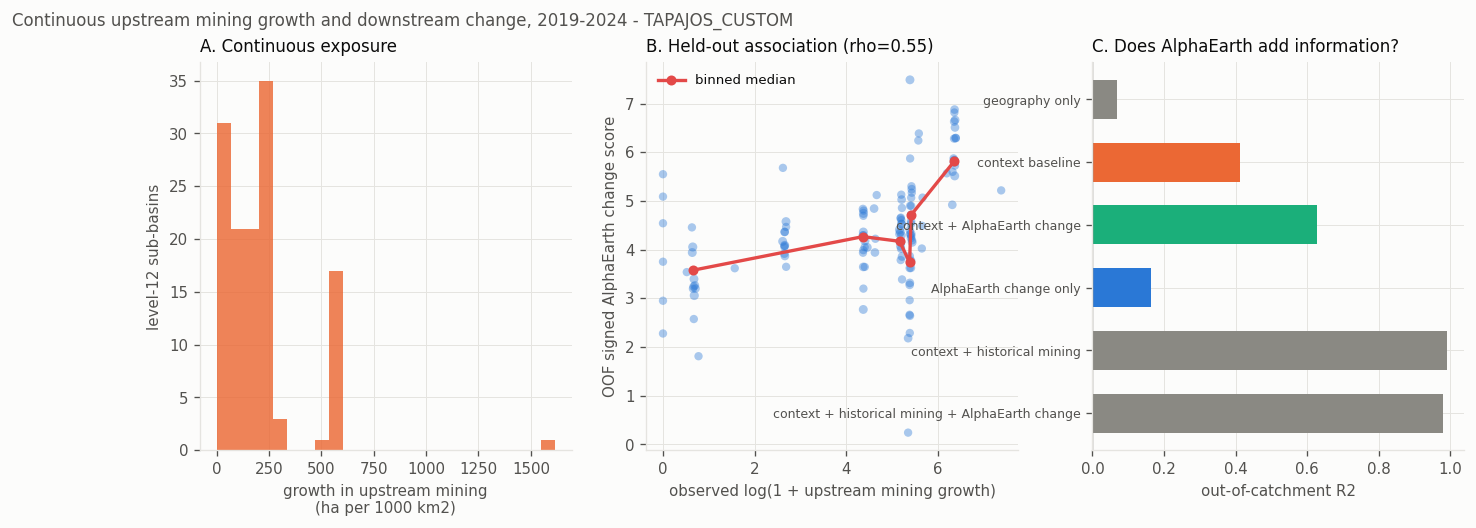


=== Primary evidence-bounded interpretation ===
SUPPORTED: AlphaEarth temporal change reduces held-out MAE beyond
non-mining geographic and river context. Report this as predictive
association with upstream mining growth, not causal pollution.

=== Historical-mining sensitivity interpretation ===
AlphaEarth does not improve the model once 2019 upstream mining is
known. This does not overturn a positive primary context-only test.

Do not interpret unsigned ||delta|| as degradation, and do not report
the old high/low classification PR-AUC as evidence of mining impact.
saved continuous-analysis tables and figure in /content/drive/MyDrive/dissertation/results_continuous_change


In [8]:
# ============================================================
# 7. Main figure and evidence-bounded conclusion
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.2))

# Panel A: the full exposure distribution retained by the new design.
axes[0].hist(bdf.ddose, bins=24, color=PAL['orange'], alpha=0.82)
axes[0].set_xlabel('growth in upstream mining\n(ha per 1000 km2)')
axes[0].set_ylabel('level-12 sub-basins')
axes[0].set_title('A. Continuous exposure', loc='left')

# Panel B: signed, out-of-catchment AlphaEarth score.
x = bdf.growth_log.values
y = bdf[delta_col].values
axes[1].scatter(x, y, s=20 + 5*np.sqrt(bdf.n_reaches),
                color=PAL['blue'], alpha=0.40, edgecolor='none')
try:
    bins = pd.qcut(pd.Series(x), q=min(6, max(3, len(bdf)//20)),
                   duplicates='drop')
    summary = pd.DataFrame({'x':x, 'y':y, 'bin':bins}).groupby(
        'bin', observed=True).agg(x=('x','median'), y=('y','median'))
    axes[1].plot(summary.x, summary.y, 'o-', color=PAL['red'],
                 label='binned median')
except ValueError:
    pass
rho = results.loc[results.model == 'AlphaEarth change only',
                  'spearman_rho'].iloc[0]
axes[1].set_xlabel('observed log(1 + upstream mining growth)')
axes[1].set_ylabel('OOF signed AlphaEarth change score')
axes[1].set_title(f'B. Held-out association (rho={rho:.2f})', loc='left')
axes[1].legend(fontsize=8)

# Panel C: primary comparison first; historical mining is a sensitivity test.
show_names = ['geography only', 'context baseline',
              'context + AlphaEarth change', 'AlphaEarth change only',
              'context + historical mining',
              'context + historical mining + AlphaEarth change']
plot_table = results.set_index('model').loc[show_names].reset_index()
positions = np.arange(len(plot_table))
colours = [PAL['muted'], PAL['orange'], PAL['green'], PAL['blue'],
           PAL['muted'], PAL['muted']]
axes[2].barh(positions, plot_table.r2, color=colours, height=0.62)
axes[2].axvline(0, color=PAL['ink2'], lw=0.8)
axes[2].set_yticks(positions)
axes[2].set_yticklabels(plot_table.model, fontsize=7.5)
axes[2].invert_yaxis()
axes[2].set_xlabel('out-of-catchment R2')
axes[2].set_title('C. Does AlphaEarth add information?', loc='left')

for axis in axes:
    axis.grid(True)
    axis.set_axisbelow(True)
fig.suptitle(
    f'Continuous upstream mining growth and downstream change, '
    f'{YEAR_PRE}-{YEAR_POST} - {BASIN_TAG}',
    x=0.01, ha='left', fontsize=10, color=PAL['ink2'])
save_fig(fig, 'F6_2_continuous_change')
plt.show()

lo = primary_increment['mae_ci_lo']
hi = primary_increment['mae_ci_hi']
gain = primary_increment['mae_gain']
print('\n=== Primary evidence-bounded interpretation ===')
if lo > 0:
    print('SUPPORTED: AlphaEarth temporal change reduces held-out MAE beyond')
    print('non-mining geographic and river context. Report this as predictive')
    print('association with upstream mining growth, not causal pollution.')
elif hi < 0:
    print('NOT SUPPORTED: adding AlphaEarth temporal change makes held-out')
    print('prediction worse than non-mining river and geographic context.')
else:
    print('INCONCLUSIVE: the catchment-bootstrap interval for AlphaEarth')
    print('incremental MAE crosses zero. The present sample cannot distinguish')
    print('a real downstream signal from geographic and river-context structure.')

slo = strict_increment['mae_ci_lo']
shi = strict_increment['mae_ci_hi']
print('\n=== Historical-mining sensitivity interpretation ===')
if slo > 0:
    print('AlphaEarth also improves prediction after 2019 upstream mining is')
    print('supplied, providing evidence beyond the unusually strong history model.')
elif shi < 0:
    print('AlphaEarth does not improve the model once 2019 upstream mining is')
    print('known. This does not overturn a positive primary context-only test.')
else:
    print('The incremental result after supplying 2019 mining history is')
    print('inconclusive under catchment bootstrap uncertainty.')

print('\nDo not interpret unsigned ||delta|| as degradation, and do not report')
print('the old high/low classification PR-AUC as evidence of mining impact.')
print('saved continuous-analysis tables and figure in', OUT_DIR)